### This figure displays a sensitivity analysis of global carbon emissions to within-country carbon elasticities for different convergence scenarios.

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

Running scenarios...
this is the cumulative emissions before cdr adjustment (from 2022) 812845500463.3389
this is the cumulative emissions after cdr adjustment (from 2022) 515345500463.33887
Goal: $5000   | Elasticity: 0.7 | Ratio: 0.50x Budget
this is the cumulative emissions before cdr adjustment (from 2022) 813433035810.0837
this is the cumulative emissions after cdr adjustment (from 2022) 515933035810.08374
Goal: $5000   | Elasticity: 0.8 | Ratio: 0.50x Budget
this is the cumulative emissions before cdr adjustment (from 2022) 813360622023.4812
this is the cumulative emissions after cdr adjustment (from 2022) 515860622023.4812
Goal: $5000   | Elasticity: 0.9 | Ratio: 0.50x Budget
this is the cumulative emissions before cdr adjustment (from 2022) 812628252586.7194
this is the cumulative emissions after cdr adjustment (from 2022) 515128252586.71936
Goal: $5000   | Elasticity: 1.0 | Ratio: 0.50x Budget
this is the cumulative emissions before cdr adjustment (from 2022) 811244563971.2057

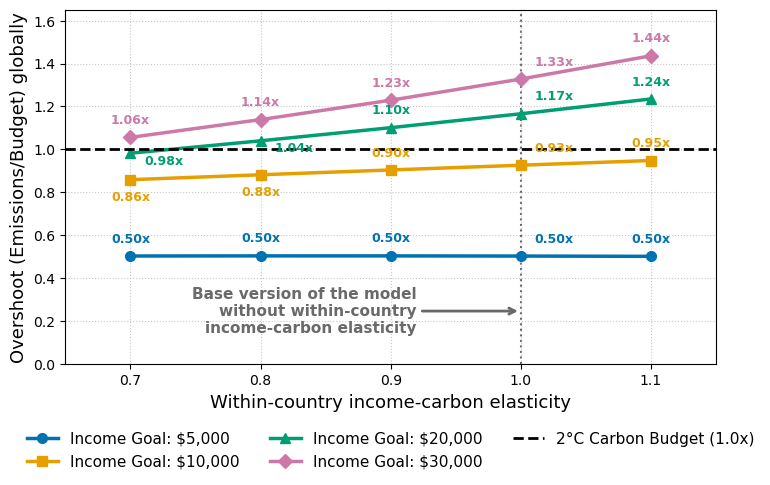

In [2]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Safely change the current working directory to the main project root.
if os.path.basename(os.getcwd()) == 'jupyter_scripts':
    os.chdir('..')

# 2. Add the 'model_code' folder to sys.path so Python can find your classes
module_path = os.path.abspath('model_code')
if module_path not in sys.path:
    sys.path.append(module_path)

from scenario_class import Scenario

# Calculate the carbon budget in Gigatonnes for later reference
carbon_budget_gt = 1150 * 0.95 - 2 * 35

# Base scenario parameters
base_scenario_params = {
    "end_year": 2100, 
    "carbon_budget": carbon_budget_gt,     
    "gdp_assumption": "constant_ratio",        
    "pop_growth_assumption": "semi_log_model",  
    "tech_evolution_assumption": "plausible", 
    "tech_hysteresis_assumption": "optimistic_degrowth", 
    "steady_state_high_income_assumption": "off",
    "kappa": 0.05,
    "t0": 2060,
    "final_improvement_rate": -0.05,
    "population_hysteresis_assumption": "on",      
    "run_until_2100": "on", 
    "cdr_assumption": "on", 
    "cdr_level_2100": 5, 
    "elasticity_assumption": "absolute_income_elasticity",
}

income_goals = [5000, 10000, 20000, 30000]
elasticities = np.arange(0.7, 1.1, 0.1)
results = []

print("Running scenarios...")
for goal in income_goals:
    for elasticity in elasticities:
        params = base_scenario_params.copy()
        params["income_goal"] = goal
        params["elasticity_value"] = elasticity
        
        scenario = Scenario(params)
        scenario.compute_country_scenario_params()
        scenario.run()
        
        # ==========================================
        # THE FIX: Use the class method to get exact 
        # cumulative emissions minus CDR (in tonnes)
        # ==========================================
        # You can adjust 'accounting_start_year' if your budget starts in a different year
        total_cumulative_emissions = scenario.sum_cumulative_emissions(accounting_start_year=2022)
        
        # Calculate standard Gt and the relative ratio
        emissions_gt = total_cumulative_emissions / 1e9
        emission_ratio = emissions_gt / carbon_budget_gt
            
        results.append({
            "Income_Goal": goal,
            "Elasticity": elasticity,
            "Cumulative_Emissions_Gt": emissions_gt,
            "Emission_Ratio": emission_ratio
        })
        print(f"Goal: ${goal:<6} | Elasticity: {elasticity:.1f} | Ratio: {emission_ratio:.2f}x Budget")


# --- Plotting the Results ---
df_results = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(8, 5))

# Okabe-Ito colorblind-friendly palette
colors = ['#0072B2', '#E69F00', '#009E73', '#CC79A7']  # Blue, Orange, Bluish Green, Reddish Purple
markers = ['o', 's', '^', 'D']  # Circle, Square, Triangle, Diamond

# Plot a line for each Income Goal scenario
for idx, goal in enumerate(income_goals):
    subset = df_results[df_results["Income_Goal"] == goal]
    
    # Plot using the new Emission_Ratio column and dynamic marker/color
    ax.plot(subset["Elasticity"], subset["Emission_Ratio"], 
            marker=markers[idx], linewidth=2.5, markersize=7, color=colors[idx],
            label=f'Income Goal: ${goal:,}')
    
    # Annotate the data points with the ratio values
    for x, y in zip(subset["Elasticity"], subset["Emission_Ratio"]):
        # Default positioning for all regular points
        x_offset = 0
        y_offset = 10
        alignment = 'center'
        
        # --- THE OVERLAP FIX ---
        # 1. If the point is on the 1.0 line, push the text to the right 
        if np.isclose(x, 1.0):
            x_offset = 10
            y_offset = 10
            alignment = 'left'
            
        # 2. Specific fix for Goal 20000 at 0.7 and 0.8 (shift down slightly and to the right)
        if goal == 20000 and (np.isclose(x, 0.7) or np.isclose(x, 0.8)):
            x_offset = 10
            y_offset = -8
            alignment = 'left'
            
        # 3. Specific fix for Goal 10000 at 0.7 and 0.8 (shift strictly below the marker)
        elif goal == 10000 and (np.isclose(x, 0.7) or np.isclose(x, 0.8)):
            x_offset = 0
            y_offset = -15
            alignment = 'center'
        
        ax.annotate(f"{y:.2f}x", 
                    (x, y), 
                    textcoords="offset points", 
                    xytext=(x_offset, y_offset), 
                    ha=alignment, 
                    fontsize=9,
                    color=colors[idx],
                    fontweight='bold')

# The reference line is now strictly 1.0 (100% of the budget)
ax.axhline(y=1.0, color='black', linestyle='--', linewidth=2, 
           label='2°C Carbon Budget (1.0x)')

# --- NEW: Annotated vertical line for the base version ---
# Calculate the visual top of the graph so the annotation stays in a clean area
top_y = df_results["Emission_Ratio"].max() * 1.15
ax.axvline(x=1.0, color='dimgrey', linestyle='dotted', linewidth=1.5, zorder=0)

# The text is distributed over 3 lines, and xytext x-coord is moved to 0.92 for a shorter arrow
ax.annotate("Base version of the model\nwithout within-country\nincome-carbon elasticity", 
            xy=(1.0, top_y * 0.15), 
            xytext=(0.92, top_y * 0.15), 
            arrowprops=dict(arrowstyle="->", color='dimgrey', lw=2),
            fontsize=11, color='dimgrey', ha='right', va='center', fontweight='bold')
# ---------------------------------------------------------

# Formatting the plot
ax.set_xlabel("Within-country income-carbon elasticity", fontsize=13)
ax.set_ylabel("Overshoot (Emissions/Budget) globally", fontsize=13)
ax.set_xticks(elasticities)

# Add some buffer to the top so annotations aren't cut off
ax.set_ylim(bottom=0, top=df_results["Emission_Ratio"].max() * 1.15) 

# Dynamically set x-limits based on your elasticity array to avoid empty margins
ax.set_xlim(left=min(elasticities) - 0.05, right=max(elasticities) + 0.05)

# --- THE UPDATED LEGEND ---
ax.legend(fontsize=11, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, framealpha=0.9, frameon=False)

ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.savefig("figures/fig6.png", dpi=300, bbox_inches='tight')
plt.show()